# **Question 4.1.1**
**Compute the derivative of the pReLU activation function.**

$$
pReLU(x)=
\begin{cases}
x, & x \ge 0,\\
ax, & x < 0.
\end{cases}
$$
then
$$
\frac{d}{dx}pReLU(x)=
\begin{cases}
1, & x \ge 0,\\
a, & x < 0.
\end{cases}
$$

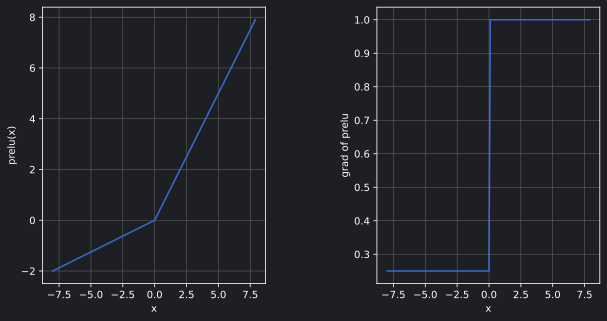

In [2]:
%matplotlib inline
import torch
from d2l import torch as d2l
x = torch.arange(-8.0, 8.0, 0.1, requires_grad=True)
y = torch.prelu(x, weight=torch.tensor(0.25))
d2l.plt.figure(figsize=(10, 5))
d2l.plt.subplot(121)
d2l.plot(x.detach(), y.detach(), 'x', 'prelu(x)', figsize=(5, 2.5))
d2l.plt.subplot(122)
y.backward(torch.ones_like(x), retain_graph=True)
d2l.plot(x.detach(), x.grad, 'x', 'grad of prelu', figsize=(5, 2.5))
d2l.plt.subplots_adjust(wspace=0.5, hspace=0)

# **Question 4.1.2**
**Prove that a multilayer perceptron using only ReLU (or pReLU) constructs a continuous piecewise linear function.**<br>
Geometrically speaking, each ReLU/pReLU neuron introduces a boundary surface at its pre-activation layer:
$$w_{i}^{T}h^{(l-1)}+b_{i}=0$$
There are a finite number of neurons in the entire network, so there are only a finite number of such hyperplanes. These hyperplanes partition the input space into a finite number of regions. Within each region, the activation state of each ReLU/pReLU is fixed; that is, each neuron either takes one linear branch or the other. Therefore, the output of each neuron within that region is an affine function of the input, and the entire network thus reduces to an affine function.<br><br>
At regional boundaries, since ReLU/pReLU is continuous and the function values do not jump, the function is continuous overall.<br><br>
Therefore, the function represented by the entire network is: A continuous piecewise linear function formed by concatenating a finite number of affine functions.

# **Question 4.1.3**
**Prove that $tanh(x) + 1 = 2sigmoid(2x)$.**<br><br>
Given:
$$tanh(x)=\frac{1-exp(-2x)}{1+exp(-2x)}$$
Therefore, the left-hand side is:
$$tanh(x)+1=\frac{1-exp(-2x)}{1+exp(-2x)}+1=\frac{2}{1+exp(-2x)}$$
At the same time, there are:
$$sigmoid(2x)=\frac{1}{1+exp(-2x)}$$
so:
$$tanh(x) + 1 = 2sigmoid(2x)$$

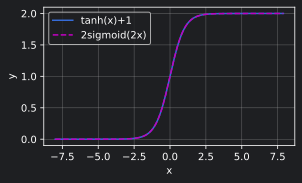

In [3]:
x = torch.arange(-8.0, 8.0, 0.1)
y1 = torch.tanh(x) + 1.0
y2 = 2.0 * torch.sigmoid(2.0 * x)
d2l.plot(x.detach().numpy(), [y1.detach(), y2.detach()], legend=['tanh(x)+1','2sigmoid(2x)'], figsize=(4.5, 2.5))
d2l.plt.xlabel('x')
d2l.plt.ylabel('y')
d2l.plt.show()

# **Question 4.1.4**
**Suppose we have a nonlinear unit; if we apply it to a small batch of data at a time, what kind of problems might this cause?**<br><br>
This typically refers to operations such as Batch Normalization: **rather than applying a nonlinear unit to each sample independently, it calculates statistics (mean, variance) for the entire mini-batch as a whole and then normalizes each sample accordingly. This leads to a series of problems.**
1. **Discrepancies Between Training and Inference Behavior<br>**
During training, BN uses the mean and variance of the current mini-batch; during inference, it typically uses the moving average accumulated during training. This results in different outputs for the same sample during training and inference, causing the model’s behavior to deviate.

2. **The samples are no longer independent of one another**<br>
Since the normalization of each sample depends on the other samples in the same batch, therefore:
    * The output of the samples affects each other;
    * Cannot be calculated independently for individual samples;
    * Online learning, streaming data, and scenarios with a batch size of 1 are virtually unusable.

3. **Very sensitive to small batch sizes**
    * When the batch size is too small, the estimates of the mean and variance are highly noisy, normalization becomes unstable, and performance degrades;
    * When the batch size is too large, memory and computational overhead increase;
    * Training performance varies with batch size and requires hyperparameter tuning.

4. **If the nonlinearity is only element-by-element, then there is no problem.**<br>
If the nonlinear units are element-wise functions such as ReLU, pReLU, or Sigmoid, then applying them to small batches is completely equivalent to applying them to individual samples, and the issues mentioned above do not arise.<br>
The problem only arises in operations that rely on batch statistics, such as BN and Softmax applied across batches.